# Hotel Cancellation — CNN Model

1D-CNN over the engineered feature vector, trained on the already cleaned/encoded/split data from `end_to_end.ipynb`. All neural network code is written in TensorFlow.

## 1. Setup

In [1]:
import numpy as np
import pandas as pd
import tensorflow as tf

print("TensorFlow:", tf.__version__)

TensorFlow: 2.20.0


## 2. Load Processed Data

Loads `X_train`, `X_test`, `Y_train`, `Y_test` from Google Drive — already cleaned, encoded, split, NaN-dropped, and scaled by `feature_prep.ipynb`. This notebook does not redo cleaning, splitting, or scaling.

In [2]:
from google.colab import drive
drive.mount("/content/drive")

Mounted at /content/drive


In [3]:
data_dir = "/content/drive/MyDrive/Colab Notebooks"

X_train = pd.read_csv(f"{data_dir}/X_train.csv")
X_test = pd.read_csv(f"{data_dir}/X_test.csv")
Y_train = pd.read_csv(f"{data_dir}/Y_train.csv")
Y_test = pd.read_csv(f"{data_dir}/Y_test.csv")

y_train = Y_train["is_canceled"].to_numpy()
y_test = Y_test["is_canceled"].to_numpy()
X_train_scaled = X_train.to_numpy()
X_test_scaled = X_test.to_numpy()

feature_cols = X_train.columns.tolist()
print(f"Feature count: {len(feature_cols)}")
print(f"X_train shape: {X_train_scaled.shape}   X_test shape: {X_test_scaled.shape}")
print(f"Train cancel rate: {y_train.mean():.3f}   Test cancel rate: {y_test.mean():.3f}")

Feature count: 42
X_train shape: (95368, 42)   X_test shape: (23840, 42)
Train cancel rate: 0.371   Test cancel rate: 0.371


## 3. Reshape for Conv1D

`Conv1D` expects `(batch, steps, channels)`. Each booking's feature vector becomes a sequence of length `n_features` with a single channel, so the convolution slides across the feature axis.

In [4]:
X_train_cnn = X_train_scaled.reshape(X_train_scaled.shape[0], X_train_scaled.shape[1], 1)
X_test_cnn = X_test_scaled.reshape(X_test_scaled.shape[0], X_test_scaled.shape[1], 1)

print(f"X_train_cnn shape: {X_train_cnn.shape}")
print(f"X_test_cnn shape: {X_test_cnn.shape}")

X_train_cnn shape: (95368, 42, 1)
X_test_cnn shape: (23840, 42, 1)


## 4. Simple Reference Model

A teammate owns the team's logistic-regression baseline separately. This is just a quick single dense + sigmoid sanity check (equivalent to logistic regression) to have an internal reference point before building the CNN.

In [5]:
simple_model = tf.keras.Sequential([
    tf.keras.layers.Input(shape=(X_train_scaled.shape[1],)),
    tf.keras.layers.Dense(1, activation="sigmoid"),
])

simple_model.compile(
    optimizer="adam",
    loss="binary_crossentropy",
    metrics=[tf.keras.metrics.AUC(name="auc"), tf.keras.metrics.AUC(name="pr_auc", curve="PR")],
)

history = simple_model.fit(
    X_train_scaled, y_train,
    validation_split=0.2,
    epochs=10,
    batch_size=256,
    verbose=1,
)

Epoch 1/10
299/299 ━━━━━━━━━━━━━━━━━━━━ 8s 21ms/step - auc: 0.6963 - loss: 0.6159 - pr_auc: 0.5439 - val_auc: 0.8074 - val_loss: 0.5210 - val_pr_auc: 0.7623
Epoch 2/10
299/299 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - auc: 0.8336 - loss: 0.4887 - pr_auc: 0.7934 - val_auc: 0.8555 - val_loss: 0.4602 - val_pr_auc: 0.8162
Epoch 3/10
299/299 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - auc: 0.8597 - loss: 0.4490 - pr_auc: 0.8205 - val_auc: 0.8672 - val_loss: 0.4356 - val_pr_auc: 0.8275
Epoch 4/10
299/299 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - auc: 0.8677 - loss: 0.4310 - pr_auc: 0.8287 - val_auc: 0.8726 - val_loss: 0.4230 - val_pr_auc: 0.8322
Epoch 5/10
299/299 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - auc: 0.8720 - loss: 0.4211 - pr_auc: 0.8327 - val_auc: 0.8753 - val_loss: 0.4158 - val_pr_auc: 0.8350
Epoch 6/10
299/299 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - auc: 0.8745 - loss: 0.4151 - pr_auc: 0.8350 - val_auc: 0.8772 - val_loss: 0.4111 - val_pr_auc: 0.8369
Epoch 7/10
299/299 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - auc: 0.87

In [6]:
simple_test_metrics = simple_model.evaluate(X_test_scaled, y_test, verbose=0)
print(dict(zip(simple_model.metrics_names, simple_test_metrics)))

{'loss': 0.40450286865234375, 'compile_metrics': 0.8785895705223083}


## 5. CNN Architecture

Each booking has 42 scaled features, treated as a length-42 sequence with one channel. `Conv1D` slides filters across neighboring features to learn interactions between them, similar to how it learns patterns across pixels in an image.

Layer-by-layer:
- **Conv1D**: learns local feature-combination filters, using fewer parameters than a full dense layer.
- **BatchNorm**: keeps activations stable between conv blocks and adds mild regularization.
- **ReLU**: adds nonlinearity so the stacked conv blocks aren't just a linear model.
- **Second Conv1D block**: combines the first block's patterns into higher-level ones, without overfitting on only 42 inputs.
- **GlobalAveragePooling1D**: shrinks the sequence to a fixed-size vector without adding parameters (unlike `Flatten`, which would tie layer size to `n_features` and overfit faster).
- **Dense + Dropout**: combines pooled features into a prediction; dropout helps prevent the model from memorizing the majority class under class imbalance.
- **Dense(1, sigmoid)**: outputs a cancellation probability.

In [12]:
def build_cnn_model(n_features, conv_filters=(32, 64), kernel_size=3,
                     dense_units=32, dropout_rate=0.3):
    inputs = tf.keras.layers.Input(shape=(n_features, 1))
    x = inputs
    for filters in conv_filters:
        x = tf.keras.layers.Conv1D(filters, kernel_size, padding="same")(x)
        x = tf.keras.layers.BatchNormalization()(x)
        x = tf.keras.layers.ReLU()(x)
    x = tf.keras.layers.GlobalAveragePooling1D()(x)
    x = tf.keras.layers.Dense(dense_units, activation="relu")(x)
    x = tf.keras.layers.Dropout(dropout_rate)(x)
    outputs = tf.keras.layers.Dense(1, activation="sigmoid")(x)
    return tf.keras.Model(inputs, outputs, name="hotel_cancellation_cnn")


cnn_model = build_cnn_model(n_features=X_train_cnn.shape[1])
cnn_model.summary()

Model: "hotel_cancellation_cnn"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_2 (InputLayer)      │ (None, 42, 1)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_2 (Conv1D)               │ (None, 42, 32)         │           128 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 42, 32)         │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu_2 (ReLU)                  │ (None, 42, 32)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_3 (Conv1D)               │ (None, 42, 64)         │         6,208 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 42, 64)         │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu_3 (ReLU)                  │ (None, 42, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling1d_1      │ (None, 64)             │             0 │
│ (GlobalAveragePooling1D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 8,833 (34.50 KB)

 Trainable params: 8,641 (33.75 KB)

 Non-trainable params: 192 (768.00 B)

In [13]:
cnn_model.compile(
    optimizer="adam",
    loss="binary_crossentropy",
    metrics=[tf.keras.metrics.AUC(name="auc"), tf.keras.metrics.AUC(name="pr_auc", curve="PR")],
)

## 6. Handle Class Imbalance

The EDA found a ~37%/63% cancel/stay split — a moderate imbalance. `class_weight` is used in `model.fit` instead of oversampling: naive row-duplication oversampling after the split would let duplicated minority-class rows leak across a train/validation carve-out, inflating validation metrics. Reweighting the loss achieves the same rebalancing effect without touching which rows exist.

In [14]:
from sklearn.utils.class_weight import compute_class_weight

class_weight_values = compute_class_weight(
    class_weight="balanced", classes=np.unique(y_train), y=y_train
)
class_weight = {int(c): w for c, w in zip(np.unique(y_train), class_weight_values)}
print(f"Class weights: {class_weight}")

Class weights: {0: np.float64(0.7946141412121515), 1: np.float64(1.3485675499872734)}


## 7. Train / Validation Split

A stratified validation split is carved out of `train` only — `test` stays untouched until final evaluation.

In [15]:
from sklearn.model_selection import train_test_split

X_tr, X_val, y_tr, y_val = train_test_split(
    X_train_cnn, y_train, test_size=0.2, random_state=42, stratify=y_train
)
print(f"X_tr: {X_tr.shape}   X_val: {X_val.shape}")

X_tr: (76294, 42, 1)   X_val: (19074, 42, 1)


## 8. Hyperparameter Tuning

A small manual grid over conv filter width, kernel size, dropout rate, learning rate, and batch size. Each config is trained with early stopping on **validation PR-AUC** (not accuracy, which is misleading under class imbalance) and the results are logged in a table for the report's Experiments section.

**If this is slow:** make sure the Colab runtime has a GPU attached (`Runtime > Change runtime type > GPU`) — on CPU, 4 configs × up to 15 epochs over ~76k rows is the main cost. `max_epochs` and the smallest `batch_size` below are already set conservatively for speed; early stopping with `patience=3` should cut most configs off well before the cap.

In [16]:
TUNE_SAMPLE_SIZE = 8000

_, X_tune, _, y_tune = train_test_split(
    X_tr, y_tr, test_size=TUNE_SAMPLE_SIZE, random_state=42, stratify=y_tr
)
print(f"X_tune: {X_tune.shape}   Tune cancel rate: {y_tune.mean():.3f}")

X_tune: (8000, 42, 1)   Tune cancel rate: 0.371


In [17]:
max_epochs = 8

tuning_configs = [
    {"conv_filters": (16, 32), "kernel_size": 3, "dropout_rate": 0.2, "learning_rate": 1e-3, "batch_size": 512},
    {"conv_filters": (32, 64), "kernel_size": 3, "dropout_rate": 0.3, "learning_rate": 1e-3, "batch_size": 512},
    {"conv_filters": (32, 64), "kernel_size": 5, "dropout_rate": 0.3, "learning_rate": 5e-4, "batch_size": 512},
    {"conv_filters": (64, 128), "kernel_size": 3, "dropout_rate": 0.4, "learning_rate": 1e-3, "batch_size": 512},
]

tuning_results = []

for cfg in tuning_configs:
    model = build_cnn_model(
        n_features=X_tune.shape[1],
        conv_filters=cfg["conv_filters"],
        kernel_size=cfg["kernel_size"],
        dropout_rate=cfg["dropout_rate"],
    )
    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=cfg["learning_rate"], clipnorm=1.0),
        loss="binary_crossentropy",
        metrics=[tf.keras.metrics.AUC(name="auc"), tf.keras.metrics.AUC(name="pr_auc", curve="PR")],
    )
    early_stop = tf.keras.callbacks.EarlyStopping(
        monitor="val_pr_auc", mode="max", patience=2, restore_best_weights=True
    )
    history = model.fit(
        X_tune, y_tune,
        validation_data=(X_val, y_val),
        class_weight=class_weight,
        epochs=max_epochs,
        batch_size=cfg["batch_size"],
        callbacks=[early_stop, tf.keras.callbacks.TerminateOnNaN()],
        verbose=0,
    )
    val_pr_auc_history = history.history["val_pr_auc"]
    val_auc_history = history.history["val_auc"]
    diverged = bool(np.isnan(val_pr_auc_history).any())
    best_val_pr_auc = np.nanmax(val_pr_auc_history) if not np.all(np.isnan(val_pr_auc_history)) else np.nan
    best_val_auc = np.nanmax(val_auc_history) if not np.all(np.isnan(val_auc_history)) else np.nan
    tuning_results.append({
        **cfg,
        "epochs_run": len(history.history["loss"]),
        "val_pr_auc": best_val_pr_auc,
        "val_auc": best_val_auc,
        "diverged": diverged,
    })

tuning_results_df = pd.DataFrame(tuning_results).sort_values("val_pr_auc", ascending=False, na_position="last")
tuning_results_df

,conv_filters,kernel_size,dropout_rate,learning_rate,batch_size,epochs_run,val_pr_auc,val_auc,diverged
2,"(32, 64)",5,0.3,0.0005,512,8,0.604299,0.731082,False
3,"(64, 128)",3,0.4,0.0010,512,4,0.571843,0.683554,False
1,"(32, 64)",3,0.3,0.0010,512,5,0.550771,0.682032,False
0,"(16, 32)",3,0.2,0.0010,512,8,0.492262,0.665307,False


The config with the highest validation PR-AUC is selected as the final architecture and retrained on the full training set (`X_train_cnn`, combining `X_tr` and `X_val`) before evaluating on the held-out test set.

In [18]:
final_max_epochs = 25

valid_results_df = tuning_results_df.dropna(subset=["val_pr_auc"])
if valid_results_df.empty:
    raise RuntimeError("Every tuning config diverged (NaN val_pr_auc) — lower the learning rates in tuning_configs and rerun.")

best_config = valid_results_df.iloc[0].to_dict()
best_conv_filters = tuple(int(f) for f in best_config["conv_filters"])
print(f"Best config: {best_config}")

cnn_model = build_cnn_model(
    n_features=X_train_cnn.shape[1],
    conv_filters=best_conv_filters,
    kernel_size=int(best_config["kernel_size"]),
    dropout_rate=best_config["dropout_rate"],
)
cnn_model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=best_config["learning_rate"], clipnorm=1.0),
    loss="binary_crossentropy",
    metrics=[tf.keras.metrics.AUC(name="auc"), tf.keras.metrics.AUC(name="pr_auc", curve="PR")],
)

final_early_stop = tf.keras.callbacks.EarlyStopping(
    monitor="val_pr_auc", mode="max", patience=3, restore_best_weights=True
)
final_history = cnn_model.fit(
    X_train_cnn, y_train,
    validation_split=0.2,
    class_weight=class_weight,
    epochs=final_max_epochs,
    batch_size=int(best_config["batch_size"]),
    callbacks=[final_early_stop, tf.keras.callbacks.TerminateOnNaN()],
    verbose=2,
)

assert not np.isnan(final_history.history["val_pr_auc"]).any(), (
    "Final training diverged (NaN val_pr_auc) even with gradient clipping — "
    "lower best_config['learning_rate'] and rerun this cell."
)

Best config: {'conv_filters': (32, 64), 'kernel_size': 5, 'dropout_rate': 0.3, 'learning_rate': 0.0005, 'batch_size': 512, 'epochs_run': 8, 'val_pr_auc': 0.6042990684509277, 'val_auc': 0.7310819029808044, 'diverged': False}
Epoch 1/25
150/150 - 15s - 97ms/step - auc: 0.6942 - loss: 0.6364 - pr_auc: 0.5891 - val_auc: 0.7278 - val_loss: 0.8051 - val_pr_auc: 0.6325
Epoch 2/25
150/150 - 1s - 6ms/step - auc: 0.7867 - loss: 0.5637 - pr_auc: 0.7250 - val_auc: 0.7855 - val_loss: 0.7617 - val_pr_auc: 0.7139
Epoch 3/25
150/150 - 1s - 7ms/step - auc: 0.8205 - loss: 0.5198 - pr_auc: 0.7693 - val_auc: 0.8044 - val_loss: 0.5868 - val_pr_auc: 0.7524
Epoch 4/25
150/150 - 1s - 7ms/step - auc: 0.8377 - loss: 0.4945 - pr_auc: 0.7915 - val_auc: 0.8516 - val_loss: 0.4655 - val_pr_auc: 0.8090
Epoch 5/25
150/150 - 1s - 8ms/step - auc: 0.8496 - loss: 0.4774 - pr_auc: 0.8056 - val_auc: 0.8607 - val_loss: 0.5042 - val_pr_auc: 0.8201
Epoch 6/25
150/150 - 2s - 13ms/step - auc: 0.8568 - loss: 0.4668 - pr_auc: 0.81

## 9. Evaluate on Test Set

ROC-AUC, PR-AUC, and a calibration (reliability) curve on the held-out test set, matching the metrics the README commits to.

745/745 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step
Test ROC-AUC: 0.8978
Test PR-AUC: 0.8643


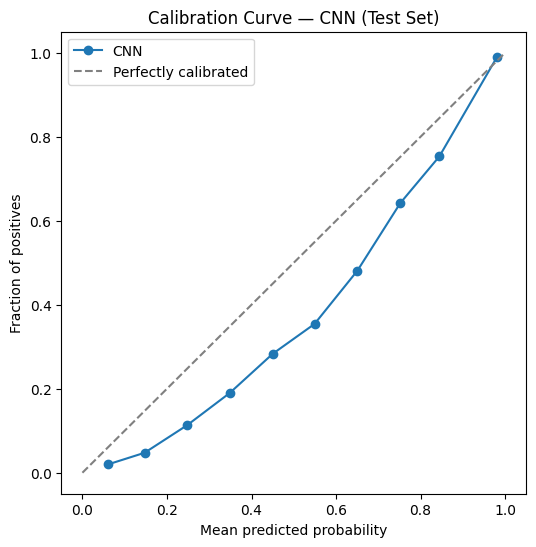

In [19]:
from sklearn.metrics import roc_auc_score, average_precision_score
from sklearn.calibration import calibration_curve
import matplotlib.pyplot as plt

y_test_proba = cnn_model.predict(X_test_cnn).ravel()

test_roc_auc = roc_auc_score(y_test, y_test_proba)
test_pr_auc = average_precision_score(y_test, y_test_proba)
print(f"Test ROC-AUC: {test_roc_auc:.4f}")
print(f"Test PR-AUC: {test_pr_auc:.4f}")

prob_true, prob_pred = calibration_curve(y_test, y_test_proba, n_bins=10)
fig, ax = plt.subplots(figsize=(6, 6))
ax.plot(prob_pred, prob_true, marker="o", label="CNN")
ax.plot([0, 1], [0, 1], linestyle="--", color="gray", label="Perfectly calibrated")
ax.set_xlabel("Mean predicted probability")
ax.set_ylabel("Fraction of positives")
ax.set_title("Calibration Curve — CNN (Test Set)")
ax.legend()
plt.show()